<a href="https://colab.research.google.com/github/mbz135/Analisis_de_datos/blob/main/Taller_1_Imagenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
!pip install pydicom
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import scipy



In [74]:
import pydicom

In [75]:
def applymask(A,B,M):

	# Perform masked addition of images using the operation: C = A*M + B*(1-M)
	#  Inputs:
	#      A,  input color image (uint8)
	#      B,  input color image (uint8)
	#      M,  input binary mask (boolean)
	#  Output:
	#      C,  output uint8 color image the
	#          same size as A, B and M
	# Edit here ################################################
  M=M.astype(bool)
  M_modificada=M[:,:,np.newaxis]  #Problema de la dimension de una imagen binaria se le agrega una tercera dimension que vale uno no altera los calculos

  A_modificada = A.astype(np.float64)
  B_modificada = B.astype(np.float64)
  C = A_modificada * M_modificada + B_modificada * (1-M_modificada)
  C=np.uint8(C)
	############################################################
  return C


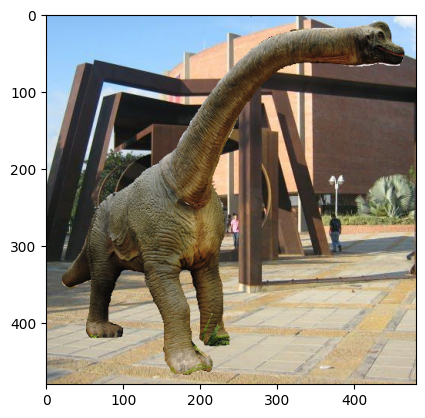

In [76]:
import matplotlib.pyplot as plt
import cv2
from solution import applymask
A = cv2.imread('/content/drive/MyDrive/testdata/dino.png')
B = cv2.imread('/content/drive/MyDrive/testdata/uis.jpg')
M = cv2.imread('/content/drive/MyDrive/testdata/mask.bmp', cv2.IMREAD_GRAYSCALE)
C = applymask(A,B,M)
fig = plt.imshow(cv2.cvtColor(C,cv2.COLOR_BGR2RGB))
plt.show()

In [77]:
def color2gray(f):
	# This function converts an input color image, f, into
	# a grayscale output image, g, using the luminance method.
	# INPUTS:
	# f,    an MxNx3 RBG uint8 color image
	# g,    an MxN grayscale image
	#
	# Edit your code here #########################
	f = f.astype(np.float64)
	g = 0.299*f[:,:,2] + 0.587*f[:,:,1] + 0.114*f[:,:,0]
	g = np.uint8(g)
	##########################################
	return g

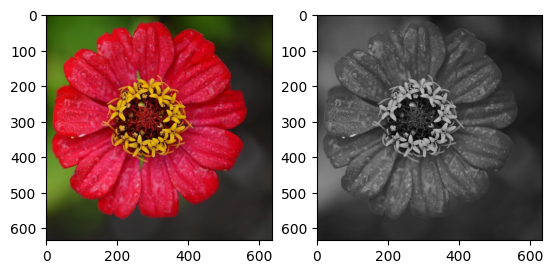

In [78]:
import matplotlib.pyplot as plt
import cv2
from solution import color2gray
A = cv2.imread('/content/drive/MyDrive/testdata/flower.bmp')
g = color2gray(A)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(cv2.cvtColor(A, cv2.COLOR_BGR2RGB))
ax2.imshow(cv2.cvtColor(g, cv2.COLOR_BGR2RGB))
plt.show()

In [79]:
def pprocess(f):
	# 	Preprocess RAW mammogram
	# Inputs:
	#     f,  MxN input RAW mammogram
	# Outputs:
	#     g,  MxN pre-processed mammogram
	#         in double format
	#
	# Edit here ######################################
	imax = 2**14 - 1   # maximo nivel de gris permitido (14 bits)
	gamma = 2.0

	g = np.clip(f.astype(np.float64), 1, imax)
	g = np.log(g)
	g = np.log(imax) - g
	g = g / np.log(imax)
	g = g ** gamma
	##############################################
	return g

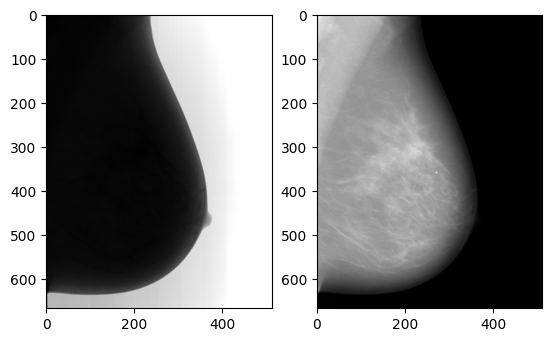

In [80]:
import matplotlib.pyplot as plt
import pydicom
from solution import pprocess

f = pydicom.dcmread('/content/drive/MyDrive/testdata/ffdm.dcm')
g = pprocess(f.pixel_array)

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(f.pixel_array, 'gray')
ax2.imshow(g, 'gray')
plt.show()


In [81]:
def amatrix(theta, s, t):
	# 	Affine transformation matrix
	# Inputs:
	#     theta,  a rotation angle (in degrees)
	#     s,      2x1 scale vector [sx; sy]
	#     t,      2x1 traslation vector [tx; ty]
	# Outputs:
	#     A,      3x3 affine transformation matrix
	#
	# Edit here ###########################################
	theta_rad = np.deg2rad(theta)

	sx, sy = s[0], s[1]
	tx, ty = t[0], t[1]

	R = np.array([
		[np.cos(theta_rad), -np.sin(theta_rad), 0],
		[np.sin(theta_rad),  np.cos(theta_rad), 0],
		[0,                  0,                 1]
	])


	S = np.array([
		[sx, 0,  0],
		[0,  sy, 0],
		[0,  0,  1]
	])


	T = np.array([
		[1, 0, tx],
		[0, 1, ty],
		[0, 0, 1]
	])

	# Se combinan: primero escala, luego rotacion, luego traslacion
	A = T @ R @ S

	#######################################################
	return A

In [94]:
import importlib
import solution

importlib.reload(solution)

amatrix = solution.amatrix

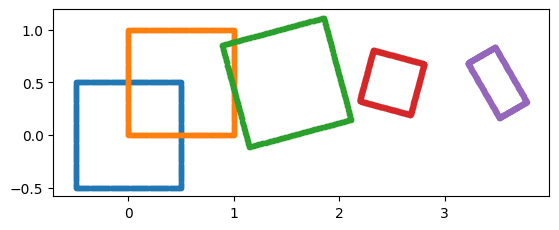

In [95]:
import matplotlib.pyplot as plt
import numpy as np
from solution import amatrix

Ps = np.loadtxt('/content/drive/MyDrive/testdata/Ps.csv', delimiter=',')

P0 = np.concatenate(
    (Ps, np.ones([1, Ps.shape[1]])),
    axis=0
)

t = np.array([[0.5], [0.5]])
s = np.array([[1], [1]])
theta = 0

A = amatrix(theta, s, t)
P1 = np.matmul(A, P0)

t = np.array([[1.5], [0.5]])
s = np.array([[1], [1]])
theta = 15

A = amatrix(theta, s, t)
P2 = np.matmul(A, P0)

t = np.array([[2.5], [0.5]])
s = np.array([[0.5], [0.5]])
theta = -15

A = amatrix(theta, s, t)
P3 = np.matmul(A, P0)

t = np.array([[3.5], [0.5]])
s = np.array([[0.3], [0.6]])
theta = 30

A = amatrix(theta, s, t)
P4 = np.matmul(A, P0)

fig, ax = plt.subplots()

ax.plot(
    P0[0, :], P0[1, :], '.',
    P1[0, :], P1[1, :], '.',
    P2[0, :], P2[1, :], '.',
    P3[0, :], P3[1, :], '.',
    P4[0, :], P4[1, :], '.'
)

ax.set_aspect('equal')
plt.show()